X_train: (140272, 43, 1)
X_val: (35069, 43, 1)
X_test: (82332, 43, 1)


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 43, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 43, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 21, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 21, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 21, 128)             │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 10, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 70)                  │          55,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 70)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              71 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 142,383 (556.18 KB)

 Trainable params: 142,383 (556.18 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9074 - loss: 0.1865
Epoch 1: val_accuracy improved from -inf to 0.99969, saving model to cnn_lstm_best.keras
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.9075 - loss: 0.1863 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 2/1000
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9999 - loss: 7.3414e-04
Epoch 2: val_accuracy did not improve from 0.99969
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step - accuracy: 0.9999 - loss: 7.3430e-04 - val_accuracy: 0.9996 - val_loss: 0.0018
Epoch 3/1000
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9997 - loss: 0.0017
Epoch 3: val_accuracy improved from 0.99969 to 0.99997, saving model to cnn_lstm_best.keras
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 1.0356e-04
Epoch 4/1000
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 3.3737e-05
Epoch 4: val_accuracy did

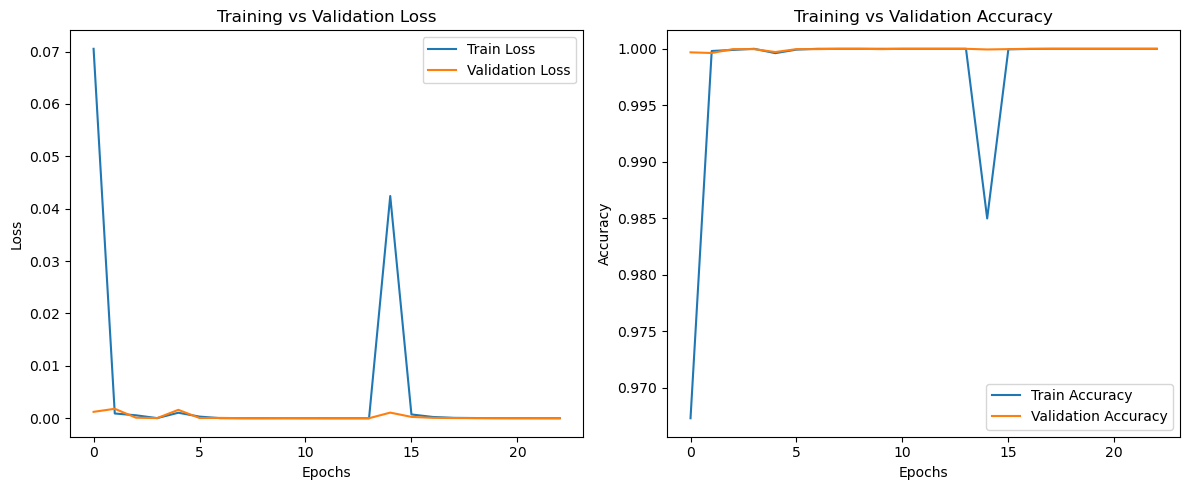


Loading best model for final evaluation...
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step

=== Classification Report (Test Data) ===
              precision    recall  f1-score   support

           0     0.9999    1.0000    0.9999     37000
           1     1.0000    0.9999    1.0000     45332

    accuracy                         1.0000     82332
   macro avg     0.9999    1.0000    1.0000     82332
weighted avg     1.0000    1.0000    1.0000     82332



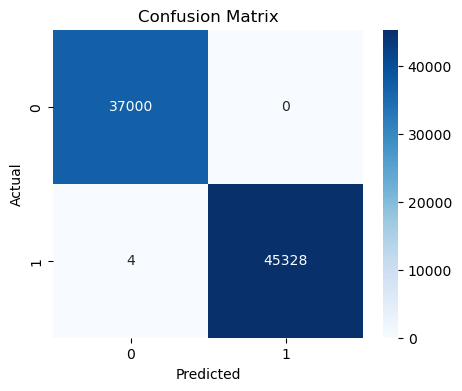

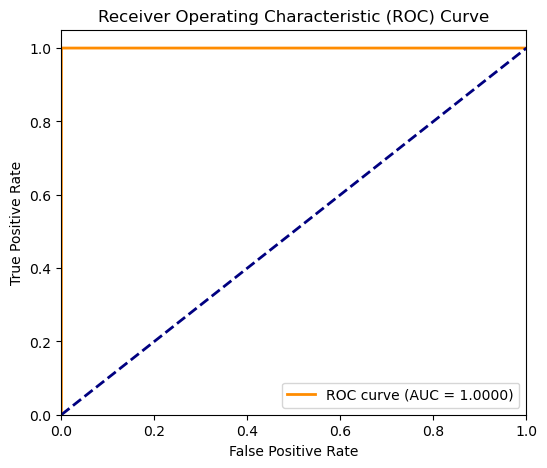


 Test ROC-AUC Score: 1.0000


In [5]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import Adam

# For reproducibility
np.random.seed(22)

# ====================================================
# Load and preprocess data
# ====================================================

train_path = "UNSW_NB15_training-set (1).csv"   # Training CSV file
test_path = "UNSW_NB15_testing-set (1).csv"    # Testing Excel file

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Droppin ID column
for df in [train_df, test_df]:
    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)

# Separate features and labels
y_train_full = train_df['label'].values
y_test = test_df['label'].values
X_train_full = train_df.drop(columns=['label'])
X_test = test_df.drop(columns=['label'])

# Replace inf/nan
for df in [X_train_full, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

# Encode categorical features safely
label_encoders = {}
for col in X_train_full.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    le.fit(X_train_full[col])
    X_train_full[col] = le.transform(X_train_full[col])
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    label_encoders[col] = le

# Normalize numeric features
scaler = MinMaxScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

# Split training set into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=22, stratify=y_train_full
)

# Reshape for CNN-LSTM: (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

# ====================================================
# Define the CNN-LSTM Model
# ====================================================

lstm_output_size = 70

model = Sequential([
    Conv1D(64, 3, padding="same", activation="relu", input_shape=(X_train.shape[1], 1)),
    Conv1D(64, 3, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2),
    Conv1D(128, 3, padding="same", activation="relu"),
    Conv1D(128, 3, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2),
    LSTM(lstm_output_size),
    Dropout(0.1),
    Dense(1, activation="sigmoid")
])

model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()

# ====================================================
# Training configuration and callbacks
# ====================================================

checkpoint = ModelCheckpoint(
    filepath="cnn_lstm_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

csv_logger = CSVLogger("training_log.csv", separator=",", append=False)

# ====================================================
# Train the model
# ====================================================

history = model.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stopping, csv_logger],
    verbose=1
)

# Save final model in new format (no HDF5 warning)
model.save("cnn_lstm_final.keras")

# ====================================================
# Plot training & validation curves
# ====================================================

log = pd.read_csv("training_log.csv")
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(log["epoch"], log["loss"], label="Train Loss")
plt.plot(log["epoch"], log["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(log["epoch"], log["accuracy"], label="Train Accuracy")
plt.plot(log["epoch"], log["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# ====================================================
# Final Evaluation on Test Data
# ====================================================

print("\nLoading best model for final evaluation...")
best_model = load_model("cnn_lstm_best.keras")

# Predict on test set
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print("\n=== Classification Report (Test Data) ===")
print(classification_report(y_test, y_pred, digits=4))

# ====================================================
# Confusion Matrix and ROC–AUC
# ====================================================

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

print(f"\n Test ROC-AUC Score: {roc_auc:.4f}")
